LAB -1 DHANUSH.V 1RUA24SCS0031

Lab 1 Implement A* Search Algorithm

Shortest Path: ['A', 'B', 'D', 'G']


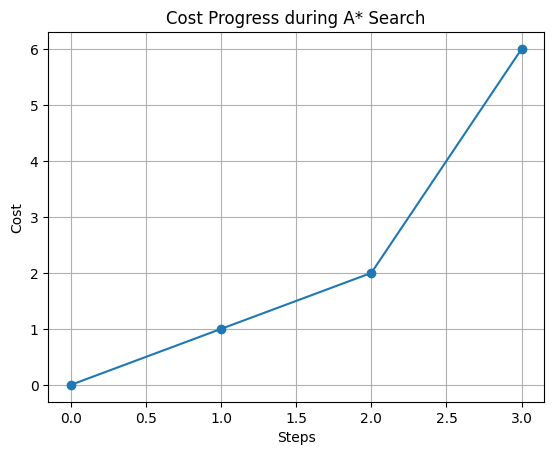

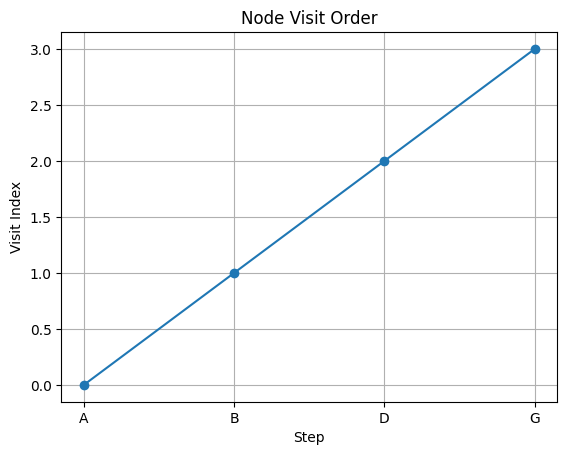

In [1]:
import heapq
import matplotlib.pyplot as plt


graph = {
    'A': {'B': 1, 'C': 3},
    'B': {'D': 1, 'E': 5},
    'C': {'F': 2},
    'D': {'G': 4},
    'E': {'G': 1},
    'F': {'G': 2},
    'G': {}
}


heuristic = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 3,
    'E': 2,
    'F': 1,
    'G': 0
}


def astar(start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0

    parent = {start: None}

    visited_order = []
    cost_progress = []

    while open_list:
        _, current = heapq.heappop(open_list)

        visited_order.append(current)
        cost_progress.append(g_cost[current])

        if current == goal:
            break

        for neighbor, cost in graph[current].items():
            new_cost = g_cost[current] + cost

            if new_cost < g_cost[neighbor]:
                g_cost[neighbor] = new_cost
                f_cost = new_cost + heuristic[neighbor]
                heapq.heappush(open_list, (f_cost, neighbor))
                parent[neighbor] = current

    
    path = []
    node = goal
    while node:
        path.append(node)
        node = parent[node]

    path.reverse()

    return path, visited_order, cost_progress


path, visited_order, cost_progress = astar('A', 'G')

print("Shortest Path:", path)



plt.figure()
plt.plot(cost_progress, marker='o')
plt.title("Cost Progress during A* Search")
plt.xlabel("Steps")
plt.ylabel("Cost")
plt.grid()
plt.show()


plt.figure()
plt.plot(range(len(visited_order)), range(len(visited_order)), marker='o')
plt.xticks(range(len(visited_order)), visited_order)
plt.title("Node Visit Order")
plt.xlabel("Step")
plt.ylabel("Visit Index")
plt.grid()
plt.show()